In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
T = 1
r = 0.05
V = 0.20
S0 = 100
K = 110
n = 252
dt = T / n
M = 50

In [3]:
precios = [S0]
for i in range(n):
    Z = np.random.normal(0, 1)

    S_nuevo = precios[-1] * np.exp((r - 0.5 * V**2) * dt+ V * np.sqrt(dt) * Z)

    precios.append(S_nuevo)


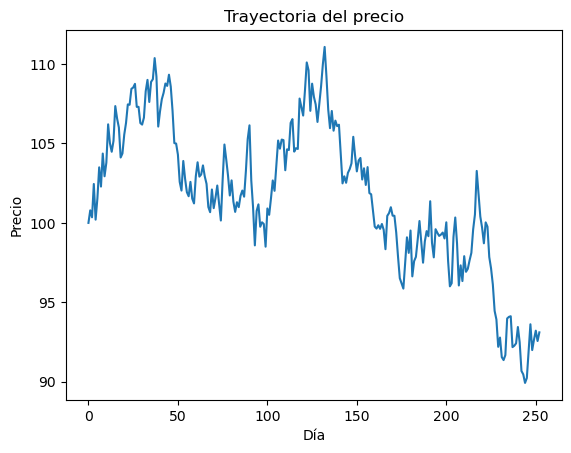

In [4]:
plt.plot(precios)

plt.xlabel("Día")
plt.ylabel("Precio")
plt.title("Trayectoria del precio")

plt.show()

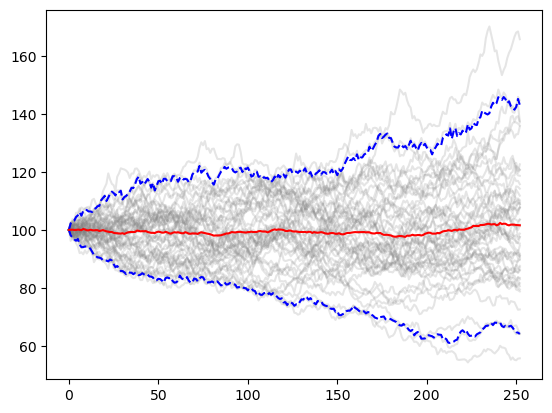

In [9]:
M = 50

trayectorias = []

for j in range(M):

    precios = [S0]

    for i in range(n):

        Z = np.random.normal(0, 1)

        S_nuevo = precios[-1] * np.exp(
            (r - 0.5 * V**2) * dt
            + V * np.sqrt(dt) * Z
        )

        precios.append(S_nuevo)

    trayectorias.append(precios)

    plt.plot(precios, color="gray", alpha=0.2)


P5 = np.percentile(trayectorias, 2.5, axis=0)
P95 = np.percentile(trayectorias, 97.5, axis=0)

media = np.mean(trayectorias, axis=0)

plt.plot(P5, color="blue", linestyle="--")
plt.plot(P95, color="blue", linestyle="--")

plt.plot(media, color="red")

plt.show()

In [10]:
M = 1000

ST = []
S_promedio = []

for j in range(M):

    precios = [S0]

    for i in range(n):

        Z = np.random.normal(0, 1)

        S_nuevo = precios[-1] * np.exp(
            (r - 0.5 * V**2) * dt
            + V * np.sqrt(dt) * Z
        )

        precios.append(S_nuevo)

    ST.append(precios[-1])
    S_promedio.append(np.mean(precios[1:]))

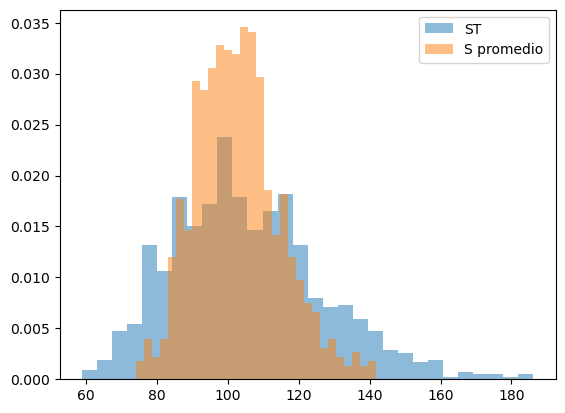

In [11]:
plt.hist(ST, bins=30, alpha=0.5, density=True, label="ST")
plt.hist(S_promedio, bins=30, alpha=0.5, density=True, label="S promedio")

plt.legend()
plt.show()

In [22]:
payoff_europea = []
payoff_asiatica = []

for i in range(M):

    # Europea: último precio de cada ruta
    payoff_europea.append(max(ST[i] - K, 0))

    # Asiática: promedio de cada ruta
    payoff_asiatica.append(max(S_promedio[i] - K, 0))
    

In [25]:
promedio_europea = np.mean(payoff_europea)
promedio_asiatica = np.mean(payoff_asiatica)

promedio_europea,promedio_asiatica

(np.float64(6.09132557360124), np.float64(2.09542106239609))